<a href="https://colab.research.google.com/github/gitWithPrince272/intelligent-model-design-using-ai-lab/blob/main/Assignment-01/IMDAI_Assignment_01_CIFAR10_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Import required libraries

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [4]:
# Load CIFAR-10 dataset

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


In [5]:
# Data preprocessing

# Normalize image pixel values from [0, 255] to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# One-hot encode the labels
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print("Training images range:", x_train.min(), "to", x_train.max())
print("Testing images range:", x_test.min(), "to", x_test.max())
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training images range: 0.0 to 1.0
Testing images range: 0.0 to 1.0
Training labels shape: (50000, 10)
Testing labels shape: (10000, 10)


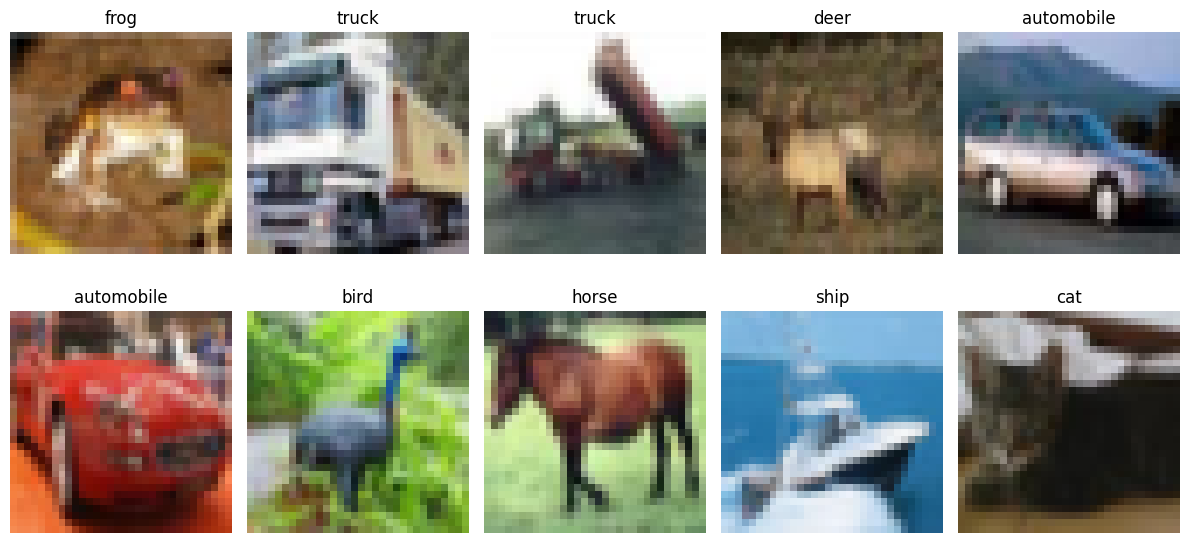

In [6]:
# CIFAR-10 class names
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Display sample images
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# Build ANN / MLP model with 3 hidden layers

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    # Convert 32x32x3 image into a 1D vector
    tf.keras.layers.Flatten(),

    # Hidden Layer 1
    tf.keras.layers.Dense(512, activation="relu"),

    # Hidden Layer 2
    tf.keras.layers.Dense(256, activation="relu"),

    # Hidden Layer 3
    tf.keras.layers.Dense(128, activation="relu"),

    # Output Layer - 10 CIFAR-10 classes
    tf.keras.layers.Dense(10, activation="softmax")
])

# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Compile the ANN model

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Display the model configuration
print("Model compiled successfully!")
print("Optimizer: Adam")
print("Learning rate: 0.001")
print("Loss function: Categorical Crossentropy")

Model compiled successfully!
Optimizer: Adam
Learning rate: 0.001
Loss function: Categorical Crossentropy


In [9]:
# Train the baseline ANN model

import time

start_time = time.time()

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

training_time = time.time() - start_time

print(f"\nBaseline training time: {training_time:.2f} seconds")

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.3086 - loss: 1.9144 - val_accuracy: 0.3630 - val_loss: 1.7696
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.3897 - loss: 1.7007 - val_accuracy: 0.4024 - val_loss: 1.6620
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.4219 - loss: 1.6132 - val_accuracy: 0.4244 - val_loss: 1.6207
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.4483 - loss: 1.5480 - val_accuracy: 0.4578 - val_loss: 1.5333
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.4649 - loss: 1.5030 - val_accuracy: 0.4390 - val_loss: 1.5917
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.4784 - loss: 1.4662 - val_accuracy: 0.4704 - val_loss: 1.4870
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.4906 - loss: 1.4287 - val_accuracy: 0.4728 - val_loss: 1.4813
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - accuracy: 0.5008 - loss: 1.3985 - 

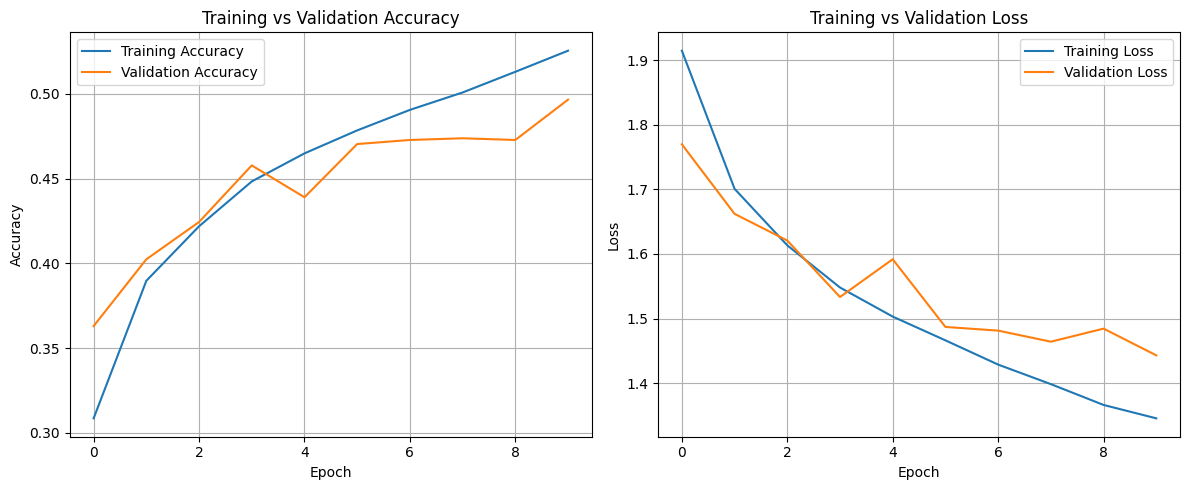

In [10]:
# Plot training and validation accuracy and loss

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
# Evaluate baseline ANN on the test dataset

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("\nBaseline Model Results")
print("----------------------")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4958 - loss: 1.4417

Baseline Model Results
----------------------
Test Loss     : 1.4417
Test Accuracy : 49.58%


<Figure size 1000x800 with 0 Axes>

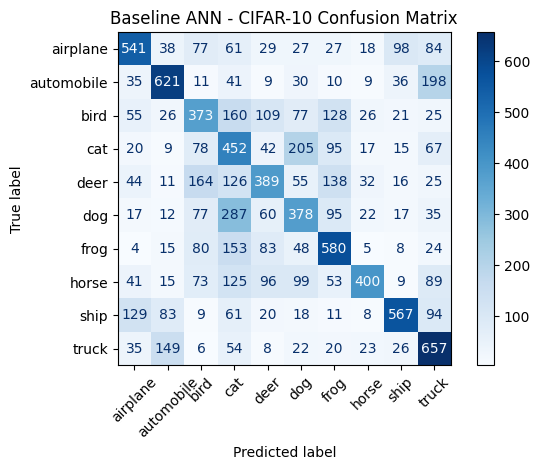

In [12]:
# Generate predictions for the test dataset

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict probabilities
y_pred_prob = model.predict(x_test, verbose=0)

# Convert one-hot encoded labels to class numbers
y_test_classes = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(y_pred_prob, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

# Display confusion matrix
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Baseline ANN - CIFAR-10 Confusion Matrix")
plt.tight_layout()
plt.show()

In [13]:
# Grid Search for ANN hyperparameter tuning

import time

grid_configs = [
    {"units": [256, 128, 64], "learning_rate": 0.001},
    {"units": [256, 128, 64], "learning_rate": 0.0005},
    {"units": [512, 256, 128], "learning_rate": 0.001},
    {"units": [512, 256, 128], "learning_rate": 0.0005}
]

grid_results = []

for i, config in enumerate(grid_configs, start=1):

    print(f"\n{'='*50}")
    print(f"Grid Search Configuration {i}")
    print(f"Hidden Units: {config['units']}")
    print(f"Learning Rate: {config['learning_rate']}")
    print(f"{'='*50}")

    # Build model
    grid_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(config["units"][0], activation="relu"),
        tf.keras.layers.Dense(config["units"][1], activation="relu"),
        tf.keras.layers.Dense(config["units"][2], activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    # Compile model
    grid_model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=config["learning_rate"]
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Training
    start_time = time.time()

    grid_history = grid_model.fit(
        x_train,
        y_train,
        epochs=5,
        batch_size=128,
        validation_split=0.1,
        verbose=0
    )

    elapsed_time = time.time() - start_time

    # Test evaluation
    test_loss_grid, test_accuracy_grid = grid_model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    # Store results
    grid_results.append({
        "Configuration": i,
        "Hidden Units": str(config["units"]),
        "Learning Rate": config["learning_rate"],
        "Test Accuracy": test_accuracy_grid,
        "Test Loss": test_loss_grid,
        "Parameters": grid_model.count_params(),
        "Training Time (sec)": elapsed_time
    })

    print(f"Test Accuracy: {test_accuracy_grid * 100:.2f}%")
    print(f"Test Loss: {test_loss_grid:.4f}")
    print(f"Parameters: {grid_model.count_params()}")
    print(f"Training Time: {elapsed_time:.2f} seconds")

print("\nGrid Search Completed!")


Grid Search Configuration 1
Hidden Units: [256, 128, 64]
Learning Rate: 0.001
Test Accuracy: 46.17%
Test Loss: 1.5001
Parameters: 828490
Training Time: 45.98 seconds

Grid Search Configuration 2
Hidden Units: [256, 128, 64]
Learning Rate: 0.0005
Test Accuracy: 45.69%
Test Loss: 1.5427
Parameters: 828490
Training Time: 43.03 seconds

Grid Search Configuration 3
Hidden Units: [512, 256, 128]
Learning Rate: 0.001
Test Accuracy: 45.31%
Test Loss: 1.5236
Parameters: 1738890
Training Time: 72.41 seconds

Grid Search Configuration 4
Hidden Units: [512, 256, 128]
Learning Rate: 0.0005
Test Accuracy: 45.96%
Test Loss: 1.5040
Parameters: 1738890
Training Time: 72.32 seconds

Grid Search Completed!


In [14]:
# Create Grid Search comparison table

import pandas as pd

grid_df = pd.DataFrame(grid_results)

# Convert accuracy to percentage
grid_df["Test Accuracy (%)"] = grid_df["Test Accuracy"] * 100

# Display selected columns
grid_comparison = grid_df[
    [
        "Configuration",
        "Hidden Units",
        "Learning Rate",
        "Test Accuracy (%)",
        "Test Loss",
        "Parameters",
        "Training Time (sec)"
    ]
]

grid_comparison

,Configuration,Hidden Units,Learning Rate,Test Accuracy (%),Test Loss,Parameters,Training Time (sec)
0,1,"[256, 128, 64]",0.0010,46.169999,1.500067,828490,45.978415
1,2,"[256, 128, 64]",0.0005,45.690000,1.542696,828490,43.026356
2,3,"[512, 256, 128]",0.0010,45.310000,1.523621,1738890,72.410067
3,4,"[512, 256, 128]",0.0005,45.960000,1.503983,1738890,72.322478


In [15]:
# Random Search for ANN hyperparameter tuning

import random
import time

random.seed(42)

hidden_options = [
    [128, 64, 32],
    [256, 128, 64],
    [384, 192, 96],
    [512, 256, 128]
]

learning_rates = [0.001, 0.0005, 0.0001]
batch_sizes = [64, 128, 256]

random_configs = []

for _ in range(4):
    config = {
        "units": random.choice(hidden_options),
        "learning_rate": random.choice(learning_rates),
        "batch_size": random.choice(batch_sizes)
    }
    random_configs.append(config)

random_results = []

for i, config in enumerate(random_configs, start=1):

    print(f"\n{'='*50}")
    print(f"Random Search Configuration {i}")
    print(f"Hidden Units: {config['units']}")
    print(f"Learning Rate: {config['learning_rate']}")
    print(f"Batch Size: {config['batch_size']}")
    print(f"{'='*50}")

    # Build ANN with exactly 3 hidden layers
    random_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(config["units"][0], activation="relu"),
        tf.keras.layers.Dense(config["units"][1], activation="relu"),
        tf.keras.layers.Dense(config["units"][2], activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    # Compile
    random_model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=config["learning_rate"]
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Train
    start_time = time.time()

    random_history = random_model.fit(
        x_train,
        y_train,
        epochs=5,
        batch_size=config["batch_size"],
        validation_split=0.1,
        verbose=0
    )

    elapsed_time = time.time() - start_time

    # Evaluate
    test_loss_random, test_accuracy_random = random_model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    # Save results
    random_results.append({
        "Configuration": i,
        "Hidden Units": str(config["units"]),
        "Learning Rate": config["learning_rate"],
        "Batch Size": config["batch_size"],
        "Test Accuracy": test_accuracy_random,
        "Test Loss": test_loss_random,
        "Parameters": random_model.count_params(),
        "Training Time (sec)": elapsed_time
    })

    print(f"Test Accuracy: {test_accuracy_random * 100:.2f}%")
    print(f"Test Loss: {test_loss_random:.4f}")
    print(f"Parameters: {random_model.count_params()}")
    print(f"Training Time: {elapsed_time:.2f} seconds")

print("\nRandom Search Completed!")


Random Search Configuration 1
Hidden Units: [128, 64, 32]
Learning Rate: 0.001
Batch Size: 256
Test Accuracy: 42.46%
Test Loss: 1.6049
Parameters: 404010
Training Time: 24.75 seconds

Random Search Configuration 2
Hidden Units: [384, 192, 96]
Learning Rate: 0.001
Batch Size: 64
Test Accuracy: 46.73%
Test Loss: 1.4879
Parameters: 1273450
Training Time: 78.02 seconds

Random Search Configuration 3
Hidden Units: [256, 128, 64]
Learning Rate: 0.0001
Batch Size: 64
Test Accuracy: 44.53%
Test Loss: 1.5539
Parameters: 828490
Training Time: 63.71 seconds

Random Search Configuration 4
Hidden Units: [128, 64, 32]
Learning Rate: 0.0001
Batch Size: 128
Test Accuracy: 41.67%
Test Loss: 1.6618
Parameters: 404010
Training Time: 23.10 seconds

Random Search Completed!


In [16]:
# Create Random Search comparison table

random_df = pd.DataFrame(random_results)

# Convert accuracy to percentage
random_df["Test Accuracy (%)"] = random_df["Test Accuracy"] * 100

random_comparison = random_df[
    [
        "Configuration",
        "Hidden Units",
        "Learning Rate",
        "Batch Size",
        "Test Accuracy (%)",
        "Test Loss",
        "Parameters",
        "Training Time (sec)"
    ]
]

random_comparison

,Configuration,Hidden Units,Learning Rate,Batch Size,Test Accuracy (%),Test Loss,Parameters,Training Time (sec)
0,1,"[128, 64, 32]",0.0010,256,42.460001,1.604901,404010,24.751604
1,2,"[384, 192, 96]",0.0010,64,46.730000,1.487900,1273450,78.020808
2,3,"[256, 128, 64]",0.0001,64,44.530001,1.553859,828490,63.713514
3,4,"[128, 64, 32]",0.0001,128,41.670001,1.661795,404010,23.104520


In [17]:
# Final performance comparison

comparison_data = {
    "Model": [
        "Baseline ANN",
        "Best Grid Search",
        "Best Random Search"
    ],
    "Configuration": [
        "512-256-128, LR=0.001, Batch=128",
        "256-128-64, LR=0.001, Batch=128",
        "384-192-96, LR=0.001, Batch=64"
    ],
    "Test Accuracy (%)": [
        test_accuracy * 100,
        grid_df["Test Accuracy (%)"].max(),
        random_df["Test Accuracy (%)"].max()
    ],
    "Parameters": [
        model.count_params(),
        grid_df.loc[grid_df["Test Accuracy (%)"].idxmax(), "Parameters"],
        random_df.loc[random_df["Test Accuracy (%)"].idxmax(), "Parameters"]
    ],
    "Training Time (sec)": [
        training_time,
        grid_df.loc[grid_df["Test Accuracy (%)"].idxmax(), "Training Time (sec)"],
        random_df.loc[random_df["Test Accuracy (%)"].idxmax(), "Training Time (sec)"]
    ]
}

final_comparison = pd.DataFrame(comparison_data)

final_comparison

,Model,Configuration,Test Accuracy (%),Parameters,Training Time (sec)
0,Baseline ANN,"512-256-128, LR=0.001, Batch=128",49.579999,1738890,163.525574
1,Best Grid Search,"256-128-64, LR=0.001, Batch=128",46.169999,828490,45.978415
2,Best Random Search,"384-192-96, LR=0.001, Batch=64",46.730000,1273450,78.020808


In [18]:
# Select the best performing model

best_model = model
best_model_name = "Baseline ANN"

print("Final Selected Model:", best_model_name)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print(f"Parameters: {best_model.count_params()}")
print(f"Training Time: {training_time:.2f} seconds")

Final Selected Model: Baseline ANN
Test Accuracy: 49.58%
Test Loss: 1.4417
Parameters: 1738890
Training Time: 163.53 seconds


In [19]:
# Save the final trained ANN model

best_model.save("cifar10_ann_baseline.keras")

print("Final model saved successfully!")

Final model saved successfully!


In [20]:
# Save training history and final results

import json

# Save training history
history_data = {
    key: [float(value) for value in values]
    for key, values in history.history.items()
}

with open("training_history.json", "w") as f:
    json.dump(history_data, f, indent=4)

# Save final model results
final_results = {
    "model": best_model_name,
    "architecture": "512-256-128",
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "batch_size": 128,
    "epochs": 10,
    "test_accuracy": float(test_accuracy),
    "test_loss": float(test_loss),
    "parameters": int(best_model.count_params()),
    "training_time_seconds": float(training_time)
}

with open("final_results.json", "w") as f:
    json.dump(final_results, f, indent=4)

print("Training history saved: training_history.json")
print("Final results saved: final_results.json")

Training history saved: training_history.json
Final results saved: final_results.json


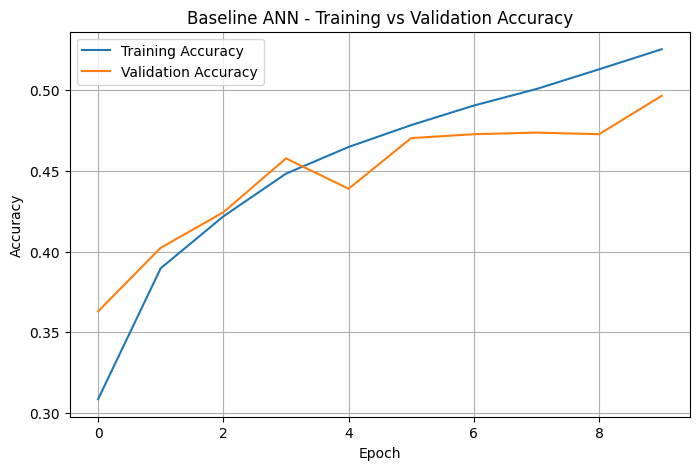

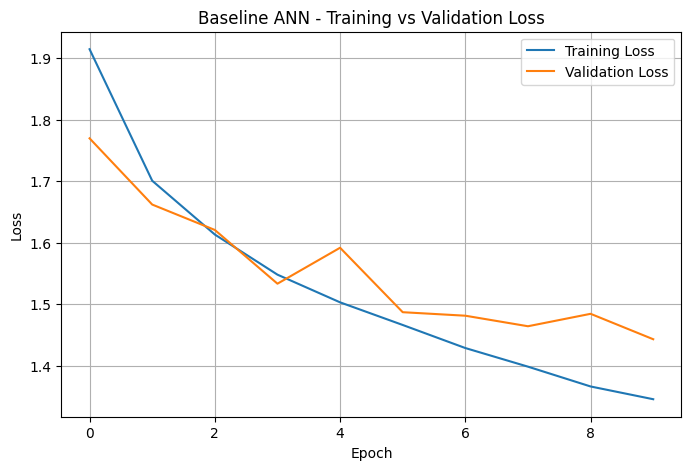

Plots saved successfully!
accuracy_plot.png
loss_plot.png


In [21]:
# Save training and validation plots

# Accuracy plot
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Baseline ANN - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig("accuracy_plot.png", dpi=300, bbox_inches="tight")
plt.show()


# Loss plot
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Baseline ANN - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig("loss_plot.png", dpi=300, bbox_inches="tight")
plt.show()

print("Plots saved successfully!")
print("accuracy_plot.png")
print("loss_plot.png")

<Figure size 1000x800 with 0 Axes>

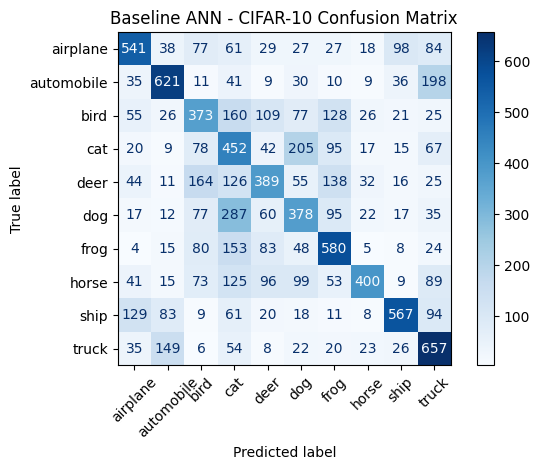

Confusion matrix saved successfully!
confusion_matrix.png


In [22]:
# Save the confusion matrix as an image

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Baseline ANN - CIFAR-10 Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved successfully!")
print("confusion_matrix.png")

In [23]:
# Save all comparison tables as CSV files

# Grid Search results
grid_comparison.to_csv(
    "grid_search_results.csv",
    index=False
)

# Random Search results
random_comparison.to_csv(
    "random_search_results.csv",
    index=False
)

# Final comparison
final_comparison.to_csv(
    "final_model_comparison.csv",
    index=False
)

print("Comparison tables saved successfully!")
print("grid_search_results.csv")
print("random_search_results.csv")
print("final_model_comparison.csv")

Comparison tables saved successfully!
grid_search_results.csv
random_search_results.csv
final_model_comparison.csv


# IMDAI Lab Assignment 01
## CIFAR-10 Image Classification using ANN/MLP + Hyperparameter Tuning

### 1. Objective

The objective of this experiment is to implement an Artificial Neural Network (ANN/MLP) for CIFAR-10 image classification and perform hyperparameter tuning using Grid Search and Random Search.

### 2. Dataset

The CIFAR-10 dataset was used for this experiment. It contains 10 classes of 32×32 RGB color images.

The standard CIFAR-10 split was used:

- Training images: 50,000
- Testing images: 10,000
- Number of classes: 10
- Image size: 32×32×3

### 3. Data Preprocessing

The following preprocessing steps were performed:

- Pixel values were normalized from the range [0, 255] to [0, 1].
- Class labels were converted into one-hot encoded vectors.
- The standard CIFAR-10 training and testing split was used.

### 4. ANN Architecture

A Multilayer Perceptron (MLP) with three hidden layers was implemented.

Architecture:

Input (32×32×3)
→ Flatten
→ Dense Layer (512 neurons, ReLU)
→ Dense Layer (256 neurons, ReLU)
→ Dense Layer (128 neurons, ReLU)
→ Output Layer (10 neurons, Softmax)

The model contains 1,738,890 trainable parameters.

### 5. Baseline Model Training

The baseline ANN was trained using:

- Optimizer: Adam
- Learning rate: 0.001
- Batch size: 128
- Epochs: 10
- Loss function: Categorical Crossentropy
- Validation split: 10%

Training time was 163.53 seconds.

### 6. Baseline Model Evaluation

The baseline model achieved:

- Test Accuracy: 49.58%
- Test Loss: 1.4417

A confusion matrix was generated to analyze the classification performance across all ten CIFAR-10 classes.

### 7. Hyperparameter Tuning

Two hyperparameter tuning approaches were implemented:

#### Grid Search

Four configurations were tested by varying hidden layer sizes and learning rate.

The best Grid Search configuration achieved:

- Hidden layers: 256-128-64
- Learning rate: 0.001
- Test Accuracy: 46.17%

#### Random Search

Four randomly selected configurations were tested by varying hidden layer sizes, learning rate, and batch size.

The best Random Search configuration achieved:

- Hidden layers: 384-192-96
- Learning rate: 0.001
- Batch size: 64
- Test Accuracy: 46.73%

### 8. Performance Comparison

| Model | Test Accuracy |
|---|---:|
| Baseline ANN | 49.58% |
| Best Grid Search | 46.17% |
| Best Random Search | 46.73% |

The baseline ANN achieved the highest test accuracy among the tested configurations.

### 9. Discussion

The baseline ANN achieved 49.58% test accuracy. The Grid Search and Random Search configurations achieved lower test accuracy in this experiment.

The tuning configurations were trained for 5 epochs, whereas the baseline model was trained for 10 epochs. Therefore, the comparison should be interpreted with this difference in training duration in mind.

The confusion matrix shows that some classes were classified more accurately than others, while visually similar classes such as bird, cat, deer, and dog showed more confusion.

### 10. Conclusion

A three-hidden-layer ANN/MLP was successfully implemented for CIFAR-10 image classification. The dataset was normalized and labels were one-hot encoded. The model was trained and evaluated using accuracy and loss metrics, and a confusion matrix was generated.

Grid Search and Random Search were also implemented for hyperparameter tuning. Among the tested configurations, the baseline ANN achieved the highest test accuracy of 49.58%.